In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
import os
import sys
from path import PathFinder
from pathlib import Path
PATHS = PathFinder()
# DIR_OUT = PATHS["DIR_TMP"] / "b0402_out"
DIR_OUT = PATHS["DIR_SRC"] / "out" 

Successfully loaded /home/niche/COLO/.env
Available project environments: 
    DIR_SRC=/home/niche/COLO
    DIR_DATA=/home/niche/data/cow-colo
    LIB_PYNICHE=/home/niche/pyniche
    DIR_TMP=/home/niche/data/tmp_colo


In [ ]:
# Collect all event files (TensorBoard logs usually start with "events.out.tfevents.")
tensorboard_files = list(DIR_OUT.rglob("events.out.tfevents.*"))

In [ ]:
filename = f"study1/thread_{t}/0_all_{m}_128/iter_1/events.out"
match_file = [f for f in tensorboard_files if filename in str(f)]
match_file[0]

PosixPath('/home/niche/COLO/out/study1/thread_3/0_all_yolo12x_128/iter_1/events.out.tfevents.1743668051.tc-gpu001.2549145.0')

Available tags:
{'images': [], 'audio': [], 'histograms': [], 'scalars': ['train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss'], 'distributions': [], 'tensors': [], 'graph': True, 'meta_graph': False, 'run_metadata': ['step1']}


Text(0.5, 0, 'Step')

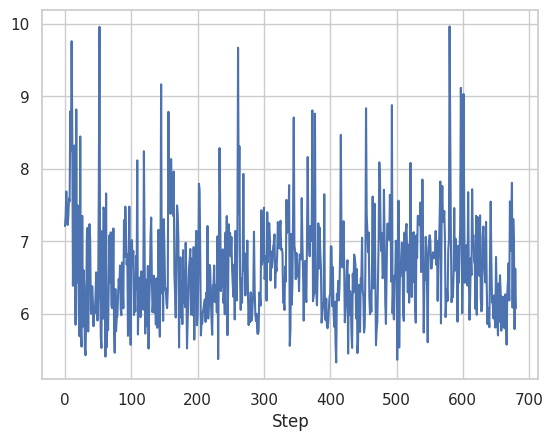

In [ ]:
from tensorboard.backend.event_processing import event_accumulator
tfile = tensorboard_files[0]

# Load an event file
ea = event_accumulator.EventAccumulator(str(tfile))
ea.Reload()
# Inspect available data types
print("Available tags:")
print(ea.Tags())
events = ea.Scalars("train/cls_loss")  # Or any tag you logged
step_times = []
for i in range(1, len(events)):
    delta_time = events[i].wall_time - events[i - 1].wall_time
    delta_step = events[i].step - events[i - 1].step
    if delta_step > 0:
        step_times.append(delta_time / delta_step)


In [64]:
# Get scalar events (e.g., for loss)
from tensorboard.backend.event_processing import event_accumulator

def get_med_time(tfile):
    # Load an event file
    ea = event_accumulator.EventAccumulator(str(tfile))
    ea.Reload()
    events = ea.Scalars("train/cls_loss")  # Or any tag you logged
    step_times = []
    for i in range(1, len(events)):
        delta_time = events[i].wall_time - events[i - 1].wall_time
        delta_step = events[i].step - events[i - 1].step
        if delta_step > 0:
            step_times.append(delta_time / delta_step)
    mu = np.median(step_times)
    return mu

# path = "/home/niche/COLO/out/study1/thread_3/0_all_rtdetr-x_128/iter_1/events.out.tfevents.1743767613.tc-gpu001.2773203.0"
# ea = event_accumulator.EventAccumulator(str(path))
# ea.Reload()
# ea.Tags()
# events = ea.Scalars("train/box_loss")  # Or any tag you logged
# events

In [65]:
# thread in [3, 5] A100 vs L40s
# model in "yolo12x" "yolo11x" "rtdetr-x" "rtdetr-l" "yolo12n" "yolo11n"
# iter = 1
# study1/thread_{3 or 5}/0_all_{model}_128/iter_1/events.out*
ls_select = []
ls_models = []
ls_thread = []
ls_mu = []
for m in ["yolo12x", "yolo11x", "rtdetr-x", "rtdetr-l", "yolo12n", "yolo11n"]:
    for t in range(10):
        for i in range(2):
            filename = f"study1/thread_{t}/0_all_{m}_128/iter_{i}/events.out"
            match_file = [f for f in tensorboard_files if filename in str(f)]
            if len(match_file) == 0:
                continue
            path_file = PATHS["DIR_SRC"] / "out" / match_file[0]
            print(path_file)
            mu = get_med_time(path_file)
            ls_mu.append(mu)
            ls_models.append(m)
            ls_thread.append(t)
            ls_select.append(filename)
import pandas as pd
data = pd.DataFrame({
    "model": ls_models,
    "thread": ls_thread,
    "mu": ls_mu,
    "filename": ls_select
})
data

/home/niche/COLO/out/study1/thread_0/0_all_yolo12x_128/iter_1/events.out.tfevents.1743655648.tc-gpu003.3411401.0
/home/niche/COLO/out/study1/thread_1/0_all_yolo12x_128/iter_1/events.out.tfevents.1743657484.tc-gpu001.2519737.0
/home/niche/COLO/out/study1/thread_2/0_all_yolo12x_128/iter_1/events.out.tfevents.1743663203.tc-gpu003.4099743.0
/home/niche/COLO/out/study1/thread_3/0_all_yolo12x_128/iter_1/events.out.tfevents.1743668051.tc-gpu001.2549145.0
/home/niche/COLO/out/study1/thread_4/0_all_yolo12x_128/iter_1/events.out.tfevents.1743712693.tc-gpu001.2656958.0
/home/niche/COLO/out/study1/thread_5/0_all_yolo12x_128/iter_1/events.out.tfevents.1743644846.fal033.1181907.0
/home/niche/COLO/out/study1/thread_6/0_all_yolo12x_128/iter_1/events.out.tfevents.1743649677.fal033.1187071.0
/home/niche/COLO/out/study1/thread_7/0_all_yolo12x_128/iter_1/events.out.tfevents.1743647817.fal044.1689311.0
/home/niche/COLO/out/study1/thread_8/0_all_yolo12x_128/iter_1/events.out.tfevents.1743653764.fal046.27708

,model,thread,mu,filename
0,yolo12x,0,5.221078,study1/thread_0/0_all_yolo12x_128/iter_1/event...
1,yolo12x,1,5.343491,study1/thread_1/0_all_yolo12x_128/iter_1/event...
2,yolo12x,2,5.312509,study1/thread_2/0_all_yolo12x_128/iter_1/event...
3,yolo12x,3,5.210836,study1/thread_3/0_all_yolo12x_128/iter_1/event...
4,yolo12x,4,5.234777,study1/thread_4/0_all_yolo12x_128/iter_1/event...
5,yolo12x,5,5.333816,study1/thread_5/0_all_yolo12x_128/iter_1/event...
6,yolo12x,6,5.319082,study1/thread_6/0_all_yolo12x_128/iter_1/event...
7,yolo12x,7,5.303691,study1/thread_7/0_all_yolo12x_128/iter_1/event...
8,yolo12x,8,5.225213,study1/thread_8/0_all_yolo12x_128/iter_1/event...
9,yolo12x,9,5.284211,study1/thread_9/0_all_yolo12x_128/iter_1/event...


In [78]:
DICT_PARAMS = dict({
    "rtdetr-l": 45,
    "rtdetr-x": 86,
    "yolo12n": 2.6,
    "yolo12m": 20.2,
    "yolo12x": 59.1,
    "yolo11n": 2.6,
    "yolo11m": 20.1,
    "yolo11x": 56.9,
})
family = dict({
    "yolo12x": "yolo12",
    "yolo11x": "yolo11",
    "yolo12n": "yolo12",
    "yolo11n": "yolo11",
    "rtdetr-x": "rtdetr",
    "rtdetr-l": "rtdetr",
})
data["params"] = data["model"].map(DICT_PARAMS)
# thread 0-4: A100, thread 5-9: L40s
data["gpu"] = ["a100" if t < 5 else "l40s" for t in data["thread"]]
data["gpu"] = data["gpu"].astype("category")
data["family"] = data["model"].map(family)
min_mu = data["mu"].min()
data["mu_std"] = data["mu"] / min_mu

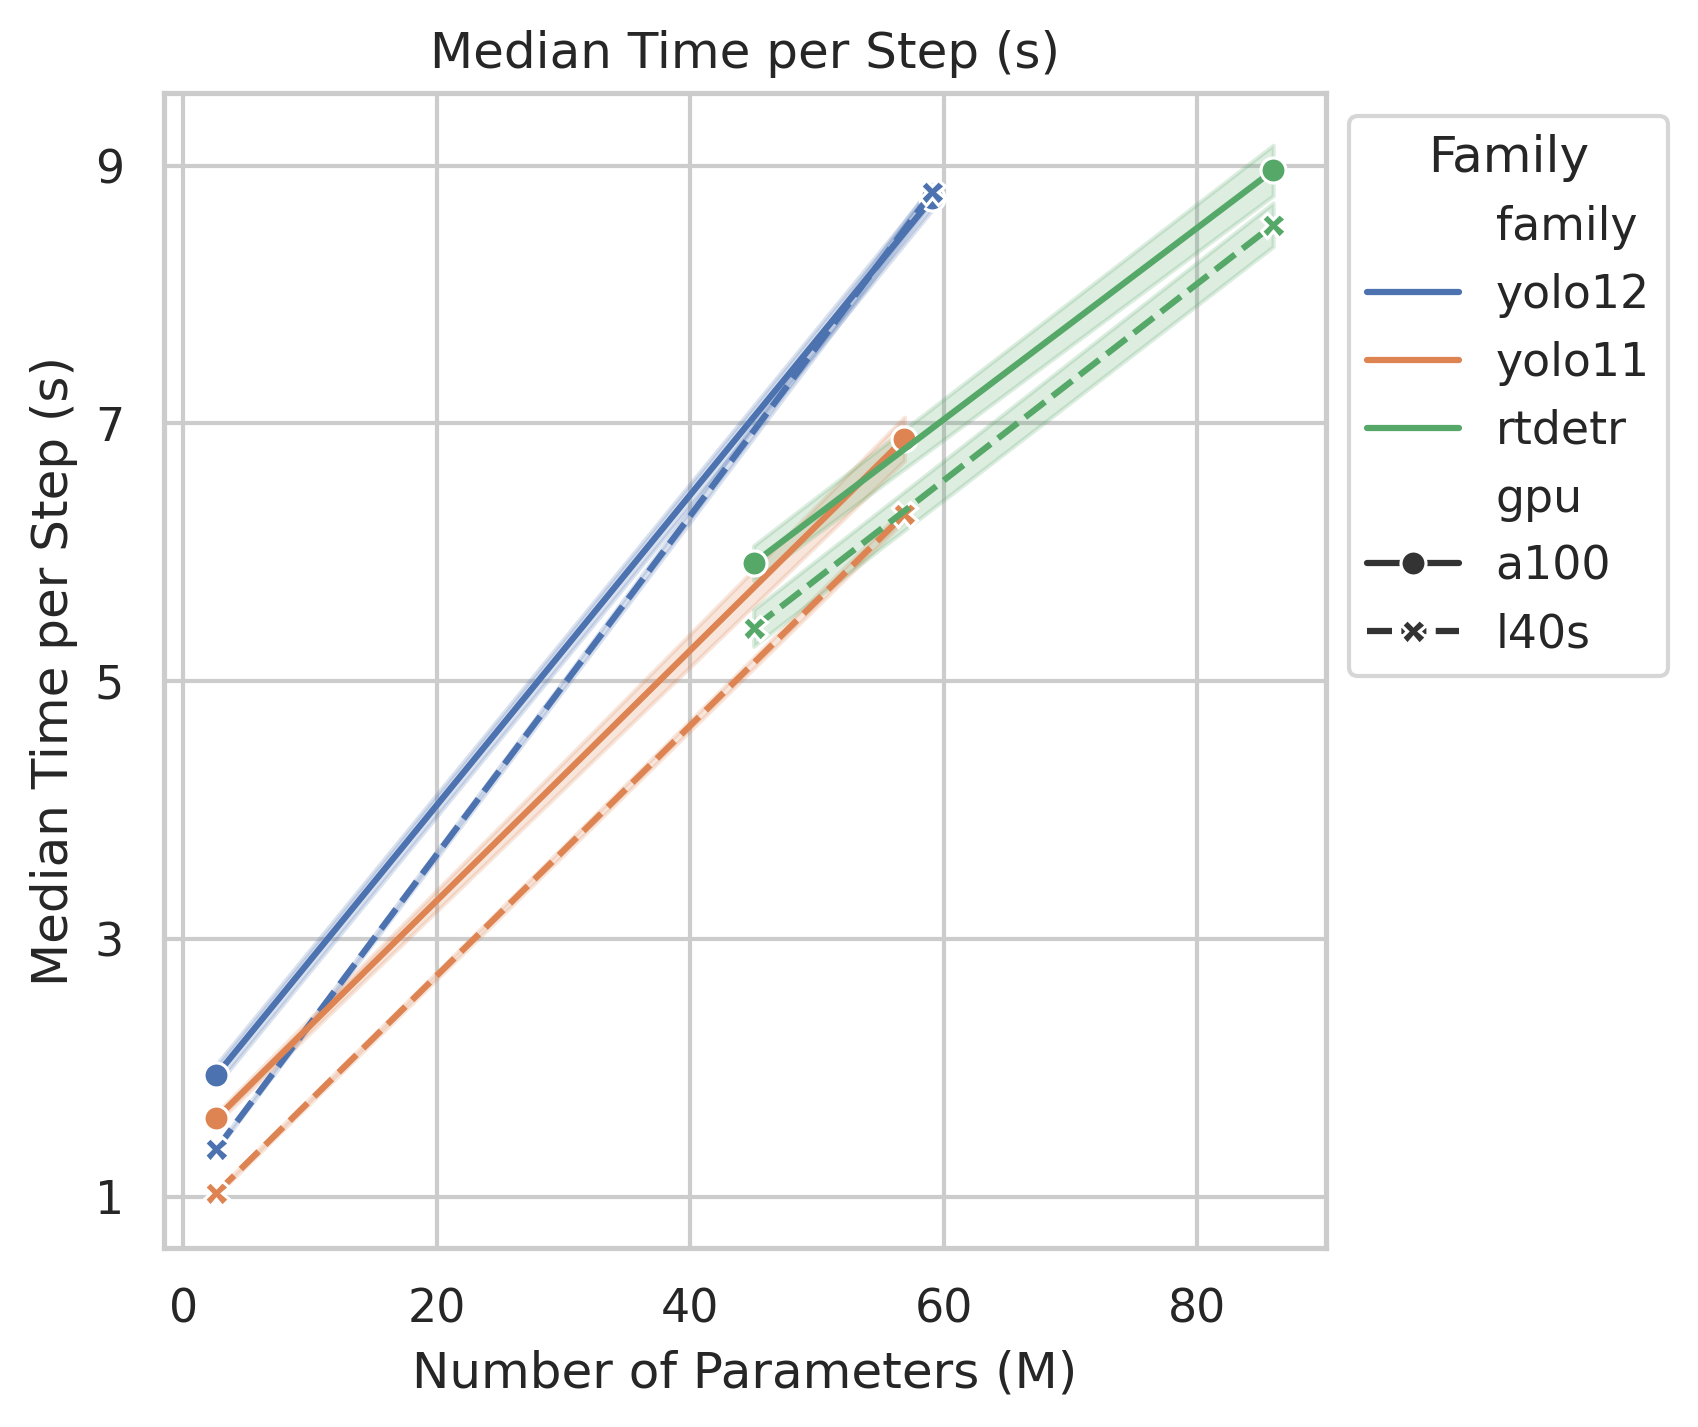

In [107]:
import seaborn as sns
import matplotlib.pyplot as plt
# line chart with marker
# x = params
# y = mu, error bar = sigma
# hue = gpu, style = family
sns.set(style="whitegrid")
plt.figure(figsize=(5, 5), dpi=300)
sns.lineplot(data=data, x="params", y="mu_std", 
             hue="family", style="gpu",
             err_style="band", errorbar=("se", 2),
             markers=True)
# y tick
plt.yticks(np.arange(1, 10, 2))
plt.xticks(np.arange(0, 100, 20))
plt.title("Median Time per Step (s)")
plt.ylabel("Median Time per Step (s)")
plt.xlabel("Number of Parameters (M)")
# move legend to the right
plt.legend(title="Family", loc="upper left", bbox_to_anchor=(1, 1))
